## Generate figures from C. elegans data

In [1]:
# plot for one worm, and code for looping over worms (no plotting)

import numpy as np
import numpy.random as npr
from scipy import io
import seaborn as sns
import time
import scipy
import pandas as pd

from functools import reduce

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

from sca.models import SCA, WeightedPCA
from sca.util import get_sample_weights,get_accuracy

# add appropriate directories to search path
import sys
sys.path.append('../generate_paper_figures/utils')

from centerOutReaching_utils import calculateEpochOccupancy
from centerOutReaching_utils import calculateOccDispersion
from centerOutReaching_utils import calculateAI
from centerOutReaching_utils import calculateChanceAI
from parallelFunctions import bootstrapNeurons_SCA_PCA

In [2]:
# directory for saving figures
figDir = '..'

In [3]:
#Load data (loads from all datasets)

load_folder='../../datasets/'

#Neural data
data=pd.read_csv(load_folder+'mating_data_traces_27june2021.csv')

#Behavioral data
beh_data=pd.read_csv(load_folder+'mating_data_motif_onsets_27june2021.csv')

In [4]:
# define two additional behavioral motifs: forward sliding and excretory pore detection
# both motifs are nested within the 'scanning' motif (Ethogram==3)
# forward sliding: Rel. Velocity < -1
# excretory pore detection: pos_y>0 & pos_x>-750 & pos_x<-250

# forward sliding
data.loc[(data['Rel.Velocity']<-1) & (data['Ethogram']==3),'Ethogram'] = 12

# excretory pore detection
data.loc[(data['pos_y']>0) & (data['pos_x']>-750) & (data['pos_x']<-250) & (data['Ethogram']==3),'Ethogram'] = 13

/var/folders/c_/3p5f6szx247fkf6ftdgp147w0000gn/T/ipykernel_5238/4219041804.py:45: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  data2=data[data['Dataset']==109]['Ethogram'][:,None].T
/var/folders/c_/3p5f6szx247fkf6ftdgp147w0000gn/T/ipykernel_5238/4219041804.py:64: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for lh in leg.legendHandles:


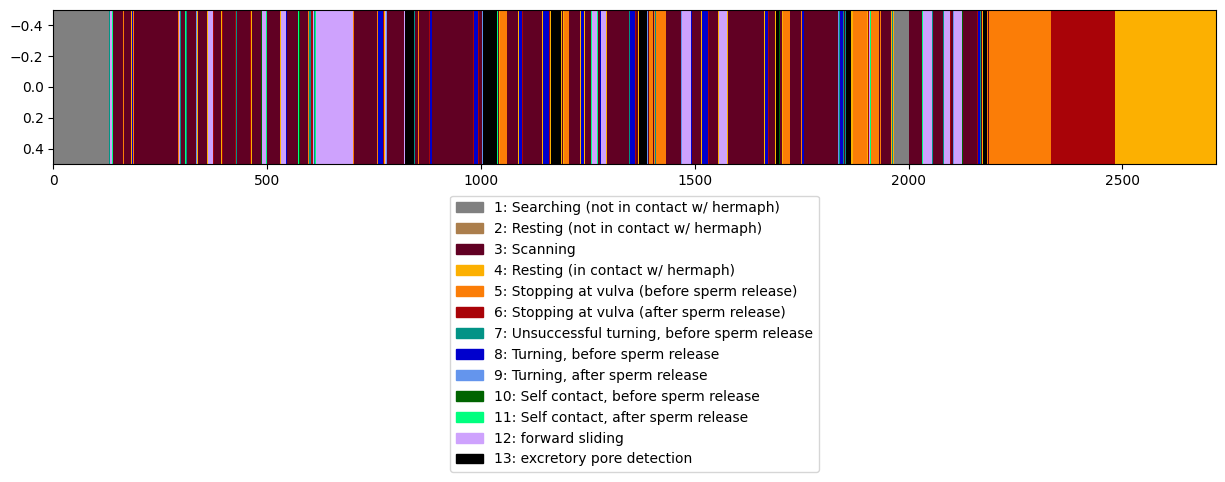

In [ ]:
## Plot ethogram (behavior) for that dataset
import matplotlib.patches as mpatches

# define a custom colormap
from matplotlib.colors import ListedColormap
colormap = ListedColormap(['grey','xkcd:tan brown','xkcd:burgundy','xkcd:yellow orange','xkcd:pumpkin orange','xkcd:darkish red','xkcd:teal',
                           'mediumblue','cornflowerblue','darkgreen','springgreen','xkcd:lilac','black'],name='cMap')

# make a list of these colors
colormapList = ['grey','xkcd:tan brown','xkcd:burgundy','xkcd:yellow orange','xkcd:pumpkin orange','xkcd:darkish red','xkcd:teal',
                           'mediumblue','cornflowerblue','darkgreen','springgreen','xkcd:lilac','black']


titles=['1: Searching (not in contact w/ hermaph)',
'2: Resting (not in contact w/ hermaph)',
'3: Scanning',
'4: Resting (in contact w/ hermaph)',
'5: Stopping at vulva (before sperm release)',
'6: Stopping at vulva (after sperm release)',
'7: Unsuccessful turning, before sperm release',
'8: Turning, before sperm release',
'9: Turning, after sperm release',
'10: Self contact, before sperm release',
'11: Self contact, after sperm release',
'12: forward sliding',
'13: excretory pore detection']



fig = plt.figure(figsize=(15,2))

alpha=1
data2=data[data['Dataset']==109]['Ethogram'][:,None].T

im=plt.imshow(data2,aspect='auto',clim=[1,13],cmap=colormap,alpha=alpha)
ax = plt.gca()
ax.grid(False)



# values = np.unique(data2.ravel())
values=np.arange(1,14)

# get the colors of the values, according to the 
# colormap used by imshow
colors = [ im.cmap(im.norm(value)) for value in values]

# create a patch (proxy artist) for every color 
patches = [ mpatches.Patch(color=colors[i], label="Level {l}".format(l=values[i]) ) for i in range(len(values)) ]

leg=plt.legend(handles= patches,labels=titles, bbox_to_anchor=(.5, -2), loc=8, borderaxespad=0)
for lh in leg.legendHandles: 
    lh.set_alpha(alpha)

subDir = figDir + 'ethograms/'
#plt.savefig(subDir + 'colormapTest.svg', dpi=2000,format='svg',bbox_extra_artists=(leg,), bbox_inches='tight' )


In [6]:
#Get the dataset numbers
datasets=list(np.unique(data['Dataset']))

# number of datasets
numDatasets = len(datasets)

#Get how many neurons per dataset
neur_per_dataset=[np.array(np.sum(~np.isnan(data.iloc[:,1:59][data['Dataset']==d]),axis=1))[0] for d in datasets]

#make a list of whether each of the 58 neurons is present in each dataset
neurons_in_dataset=[np.array(~np.isnan(data.iloc[:,1:59][data['Dataset']==d]))[0,:] for d in datasets]

#from the above list, generate a neuron x data boolean array
isNeuronHere = np.zeros((58,numDatasets))
for ii in range(numDatasets):
    isNeuronHere[:,ii] = neurons_in_dataset[ii]

# from the 8 datasets that have > 40 neurons, calculate how many neurons are shared across all of the datasets
lotsONeuronIdx = np.sum(isNeuronHere,axis=0) > 40
print('number of datasets: ' + str(np.sum(lotsONeuronIdx)))
numWorms = np.sum(lotsONeuronIdx)
numNeuronsShared_LON = np.sum(np.all(isNeuronHere[:,lotsONeuronIdx],axis=1))
print('number of shared neurons: ' + str(numNeuronsShared_LON))
print('number of neurons per worm: ' + str( np.sum(isNeuronHere[:,lotsONeuronIdx],axis=0) ))

# pull out the ID numbers for the 'good' datasets
goodIdx = np.argwhere(lotsONeuronIdx)[:,0]
goodIDs = [datasets[x] for x in goodIdx]

#Get how long (timewise) the datasets were
lens=[np.sum(data['Dataset']==d) for d in datasets]

number of datasets: 8
number of shared neurons: 33
number of neurons per worm: [49. 53. 54. 50. 49. 51. 53. 51.]


In [7]:
# plotting order for neurons
neuronOrder = [7,41,36,57,37,28,34,21,1,3,4,5,2,31,40,18,19,20,10,45,46,47,51,35,55,33,6,8,9,11,12,13,14,15,16,17,22,23,24,25,26,27,29,30,32,38,39,42,43,44,48,
               49,50,52,53,54,56,58]

# change to 0 index
neuronOrder = [x-1 for x in neuronOrder]

# second ordering
neuronOrder2 = [1,2,3,4,5,6,7,8,9,10,29,38,39,28,11,12,13,14,15,50,32,35,36,16,17,18,19,20,
                21,22,23,55,58,57,41,24,25,26,30,31,47,27,33,34,37,40,42,43,44,45,46,48,49,51,52,53,54,56]
neuronOrder2 = [x-1 for x in neuronOrder2]

#index into the first list
neuronOrder3 = [neuronOrder[x] for x in neuronOrder2]

# rename
neuronOrder = neuronOrder3

### Generate and save ethograms for each worm (only the worms with > 40 neurons have ethograms)

/var/folders/c_/3p5f6szx247fkf6ftdgp147w0000gn/T/ipykernel_5238/4078447460.py:43: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  data2=data[data['Dataset']==wormID]['Ethogram'][:,None].T
/var/folders/c_/3p5f6szx247fkf6ftdgp147w0000gn/T/ipykernel_5238/4078447460.py:59: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for lh in leg.legendHandles:


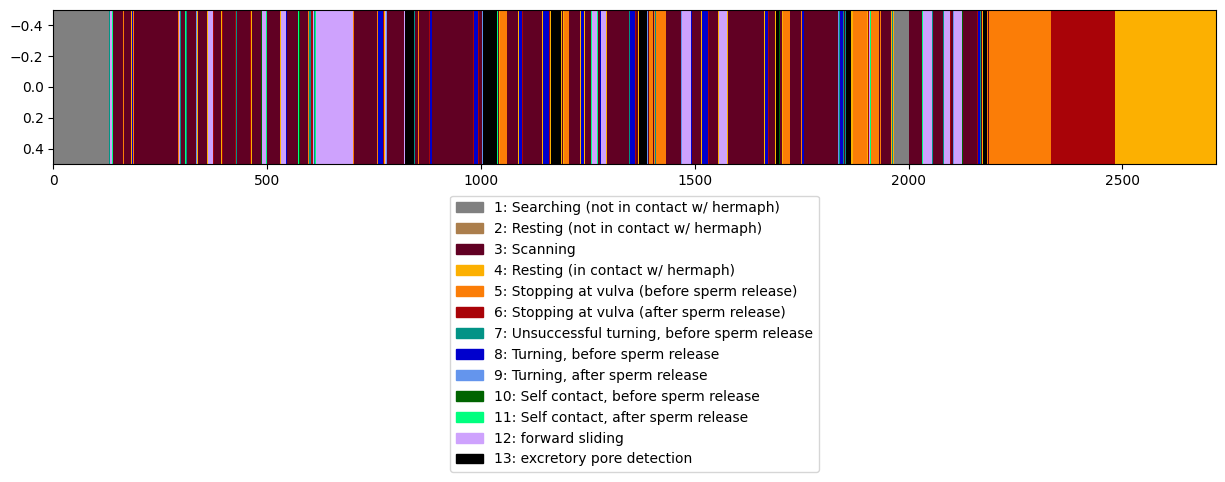

In [ ]:
# sub directory for figures
subDir = figDir + 'ethograms/'

# import a module for plotting shapes
import matplotlib.patches as mpatches

# cycle through the worms
for ii in range(1): # only plot the first worm

    # id for this worm
    wormID = goodIDs[ii]

    titles=['1: Searching (not in contact w/ hermaph)',
            '2: Resting (not in contact w/ hermaph)',
            '3: Scanning',
            '4: Resting (in contact w/ hermaph)',
            '5: Stopping at vulva (before sperm release)',
            '6: Stopping at vulva (after sperm release)',
            '7: Unsuccessful turning, before sperm release',
            '8: Turning, before sperm release',
            '9: Turning, after sperm release',
            '10: Self contact, before sperm release',
            '11: Self contact, after sperm release',
            '12: forward sliding',
            '13: excretory pore detection']


    plt.figure(figsize=(15,2))
    data2=data[data['Dataset']==wormID]['Ethogram'][:,None].T

    im=plt.imshow(data2,aspect='auto',clim=[1,13],cmap=colormap,alpha=alpha)
    ax = plt.gca()
    ax.grid(False)

    values=np.arange(1,14)

    # get the colors of the values, according to the
    # colormap used by imshow
    colors = [ im.cmap(im.norm(value)) for value in values]

    # create a patch (proxy artist) for every color
    patches = [ mpatches.Patch(color=colors[i], label="Level {l}".format(l=values[i]) ) for i in range(len(values)) ]

    leg=plt.legend(handles= patches,labels=titles, bbox_to_anchor=(.5, -2), loc=8, borderaxespad=0)
    for lh in leg.legendHandles:
        lh.set_alpha(alpha)

    plt.show()
    # save figure
    # plt.savefig(subDir + 'worm_' + str(wormID) + '.svg', dpi=2000,format='svg',bbox_extra_artists=(leg,), bbox_inches='tight' )
    # plt.close()


### Plot activity of individual neurons for each worm

In [9]:
goodIDs

[109, 137, 153, 182, 184, 185, 714, 2457]

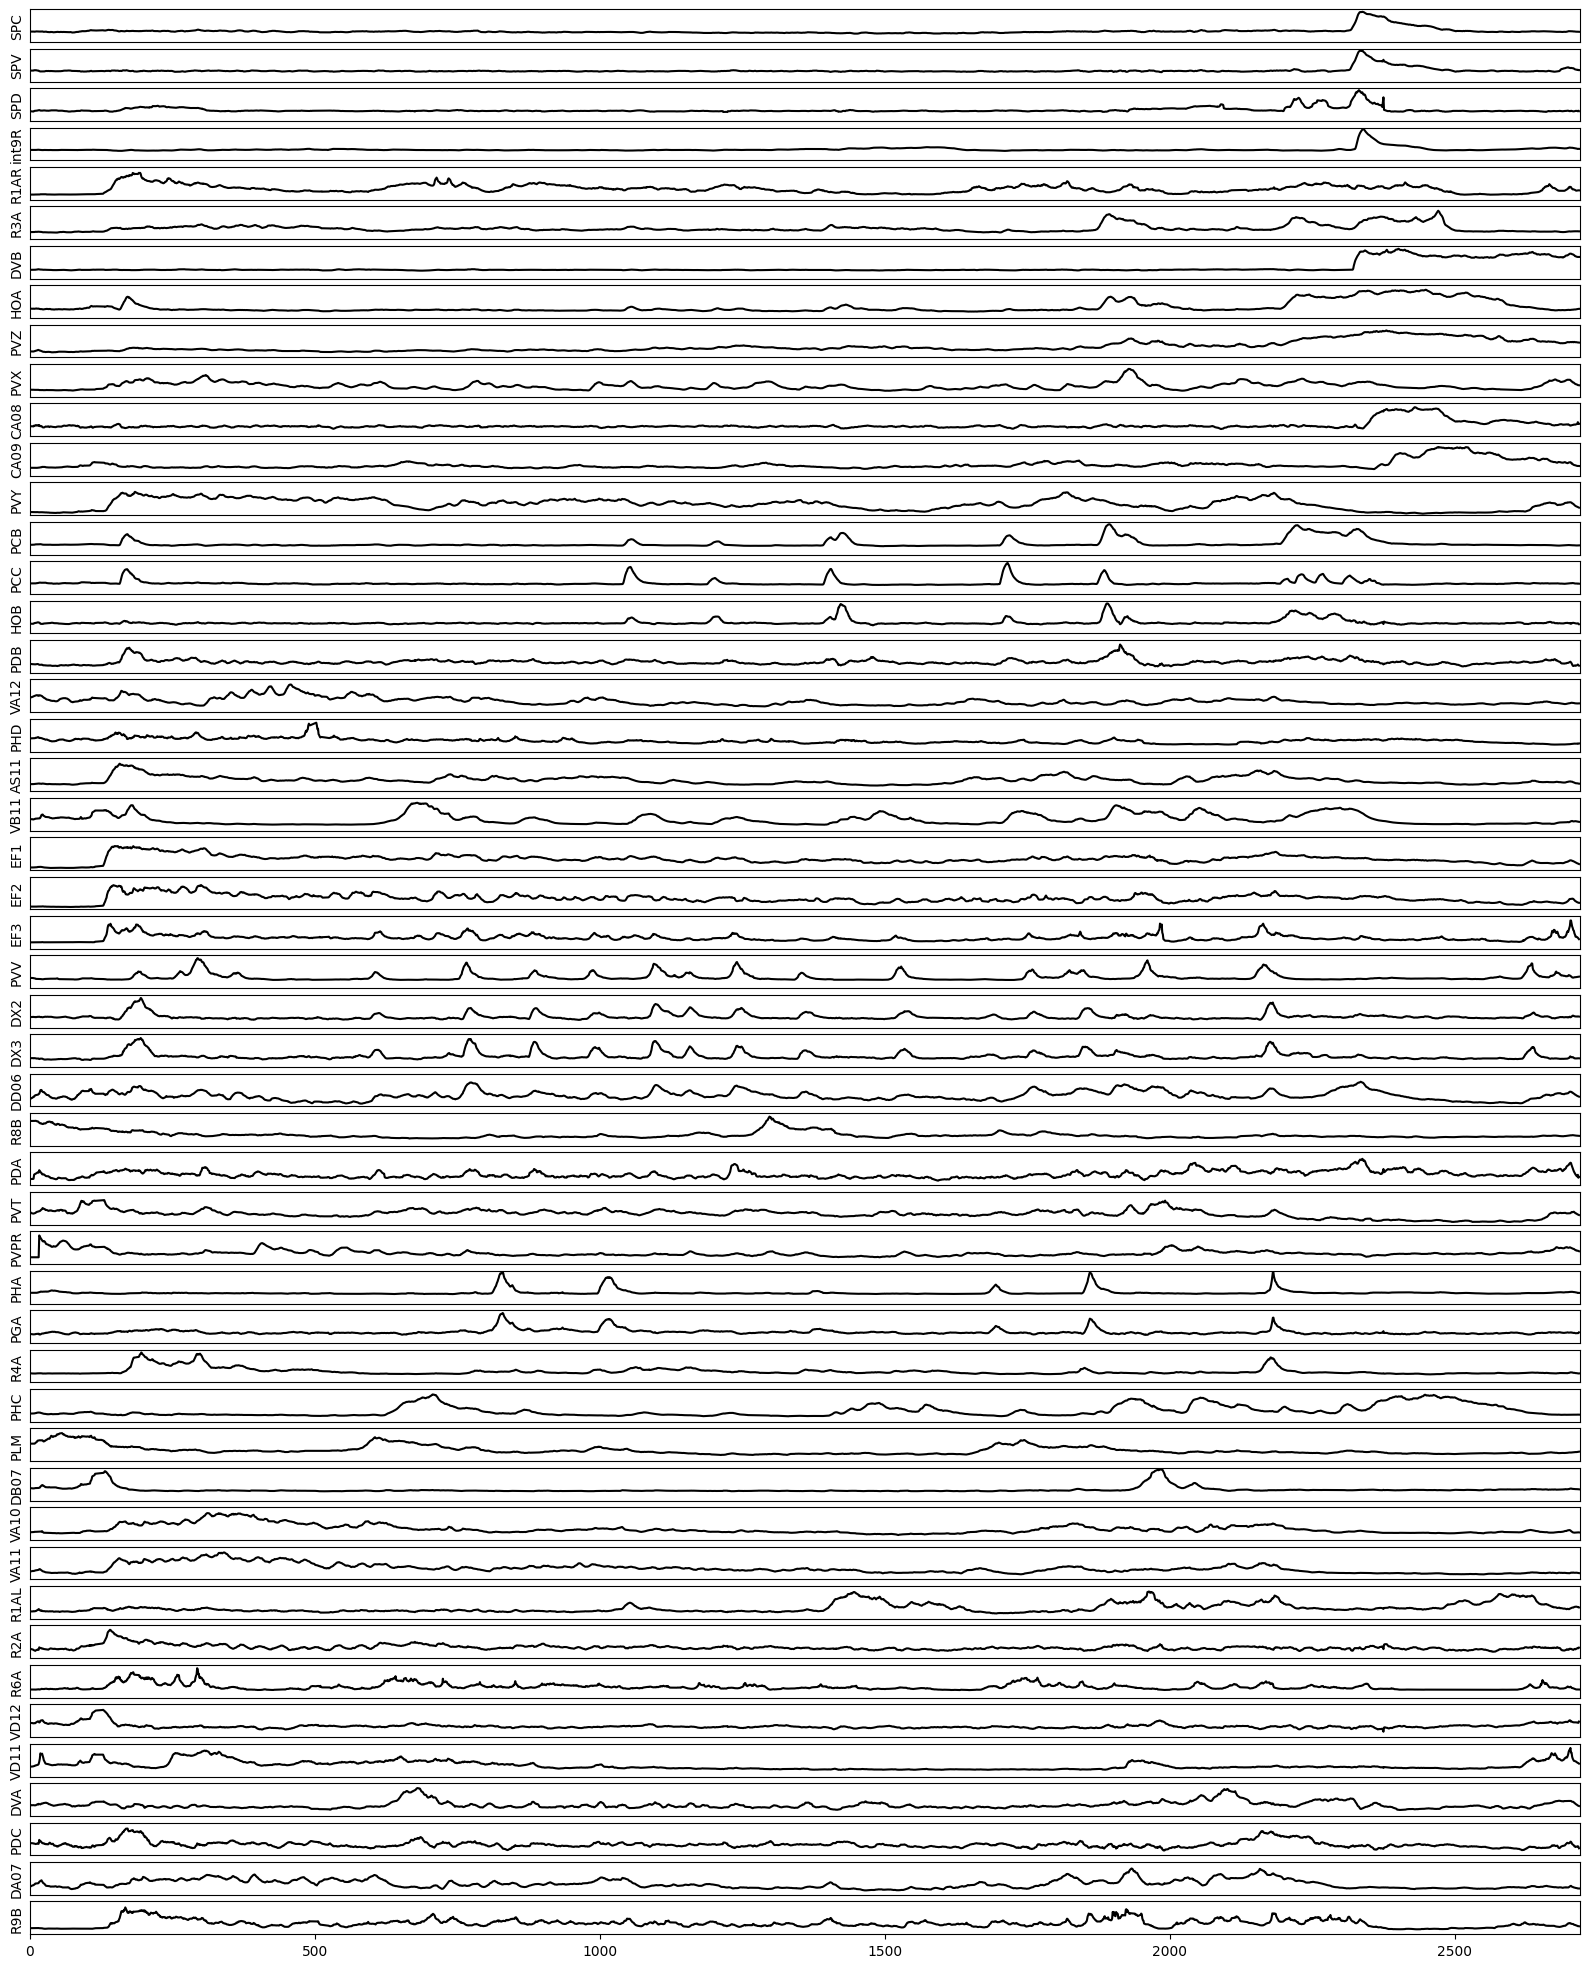

In [10]:
# sub directory for figures
subDir = figDir + 'singleNeuronTraces/'

# plotting parameters
yLimit = [-0.5, 1]
lineWidth = 1.5

# cycle through worms
for ii in range(1): # only plot the first worm

    # which worm are we working with?
    wormID = goodIDs[ii]

    #Get neurons that were recorded in the given dataset
    data_all_nrns=data.iloc[:,1:59][data['Dataset']==wormID]
    data_all_nrns = data_all_nrns.iloc[:,neuronOrder]
    data_inc_nrns=data_all_nrns.iloc[:,~np.isnan(np.array(data_all_nrns.iloc[0,:]))]

    # names of the recorded neurons
    neuronNames = data_inc_nrns.columns

    # normalize each neuron's activity by its range
    data_norm = data_inc_nrns / np.ptp(data_inc_nrns,axis=0)

    # duration of recording and number of neurons
    T,numN=data_norm.shape
    t = np.arange(0,T)

    # initialize a figure
    fig,ax=plt.subplots(numN,1,figsize=(20,25))

    for i in range(numN):

        ax[i].plot(t,data_norm.iloc[:,i],linewidth=lineWidth,color='black')

        ax[i].set_xlim([0,T])
        ax[i].set_ylim(yLimit)

        if i<numN-1:
            ax[i].set_xticks([])


        ax[i].set_yticks([])
        ax[i].set_ylabel(neuronNames[i])
        ax[i].grid(False)
        ax[i].set(facecolor='white')

    # # save figure
    # plt.savefig(subDir + 'worm_' + str(wormID) + '.svg', dpi=1000,format='svg')
    # plt.close()




## Run SCA on each individual worms, using all recorded neurons

In [11]:
# initialize a list to hold SCA and PCA latents
SCA_latents = []
PCA_latents = []

# list to hold loadings
SCA_loadings = []
PCA_loadings = []

# R2 for each worm
R2 = []

# number of dimensions
R_est=15

# sparseness penalty
lam_sparse = 0.05

for ii in range(numWorms):

    # which worm are we working with?
    wormID = goodIDs[ii]

    #Get neurons that were recorded in the given dataset
    data_all_nrns=data.iloc[:,1:59][data['Dataset']==wormID]
    data_inc_nrns=data_all_nrns.iloc[:,~np.isnan(np.array(data_all_nrns.iloc[0,:]))]

    # normalize neurons by their range
    data_norm = data_inc_nrns/np.ptp(data_inc_nrns,axis=0)

    # rename for convenience
    fit_data=np.array(data_norm)

    # get sample weights
    sample_weights = get_sample_weights(fit_data)

    # fit SCA
    sca = SCA(n_components=R_est, n_epochs=5000, lam_sparse=lam_sparse, orth=False)
    sca.fit(X=fit_data, sample_weight=sample_weights)

    # grab sca projections
    sca_latent=sca.transform(fit_data)

    # add to list
    SCA_latents.append(sca_latent)

    # grab the SCA loadings
    V = sca.params['V']

    # add to list
    SCA_loadings.append(V.T)

    # calculate R2 for sca
    x_hat = sca.reconstruct(fit_data)
    r2 = 1 - ((np.linalg.norm(fit_data- x_hat,ord='fro')**2) / (np.linalg.norm(fit_data,ord='fro')**2) )
    R2.append(r2)

    # run PCA
    wpca = WeightedPCA(n_components=R_est)
    wpca.fit(fit_data, sample_weight=sample_weights)


    # project into the PC space
    pca_latent = wpca.transform(fit_data)

    # add to the list
    PCA_latents.append(pca_latent)

    # save the loadings
    PCA_loadings.append(wpca.params['U'])

Using lam_orthog=  21.46836680285771
Using device cpu
744.41003
8153.883


100%|██████████| 5000/5000 [00:14<00:00, 333.88it/s]


Using lam_orthog=  9.745317172074056
Using device cpu
354.03314
4245.287


100%|██████████| 5000/5000 [00:10<00:00, 485.81it/s]


Using lam_orthog=  9.45425130850603
Using device cpu
431.06616
5176.204


...

100%|██████████| 5000/5000 [00:15<00:00, 323.33it/s]


Using lam_orthog=  19.374754459377982
Using device cpu
731.94196
8003.3438


100%|██████████| 5000/5000 [00:12<00:00, 391.71it/s]


Using lam_orthog=  16.368752278117576
Using device cpu
584.21826
7976.8174


100%|██████████| 5000/5000 [00:13<00:00, 374.74it/s]


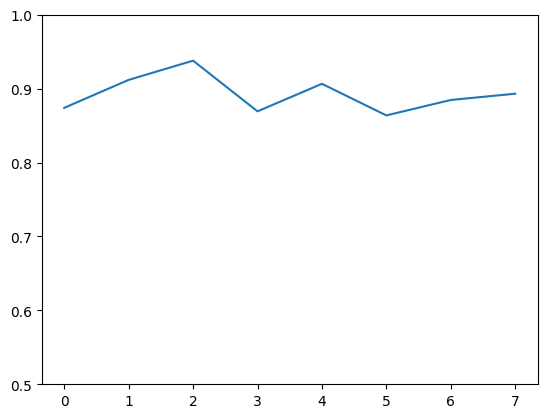

In [12]:
# plot the R2 for each worm
plt.plot(R2);
plt.ylim([0.5, 1]);

In [13]:
# for each set of SCA and PCA latents, flip each dimension if mean activity is negative

# list for SCA and PCA latents
SCA_flip = []
PCA_flip = []

# save the flips for each dimension for each worm
scaFlips = []

# cycle through each worm
for ii in range(len(SCA_latents)):

    # pull out our 2 sets of latents
    sca = SCA_latents[ii]
    pca = PCA_latents[ii]

    # calculate mean activity for each dimension and figure out if we need to flip it
    flipSCA = ((np.mean(sca,axis=0) < 0) - 0.5)*-2
    flipPCA = ((np.mean(pca,axis=0) < 0) - 0.5)*-2

    scaFlips.append(flipSCA)

    # save the flipped versions
    SCA_flip.append(sca*flipSCA)
    PCA_flip.append(pca*flipPCA)



## Plot

/var/folders/c_/3p5f6szx247fkf6ftdgp147w0000gn/T/ipykernel_5238/934893177.py:32: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ax[i].imshow(data[data['Dataset']==wormID]['Ethogram'][:,None].T,aspect='auto',clim=cLimit,cmap=colormap,alpha=alpha)
/var/folders/c_/3p5f6szx247fkf6ftdgp147w0000gn/T/ipykernel_5238/934893177.py:32: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ax[i].imshow(data[data['Dataset']==wormID]['Ethogram'][:,None].T,aspect='auto',clim=cLimit,cmap=colormap,alpha=alpha)
/var/folders/c_/3p5f6szx247fkf6ftdgp147w0000gn/T/ipykernel_5238/934893177.py:32: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy ar

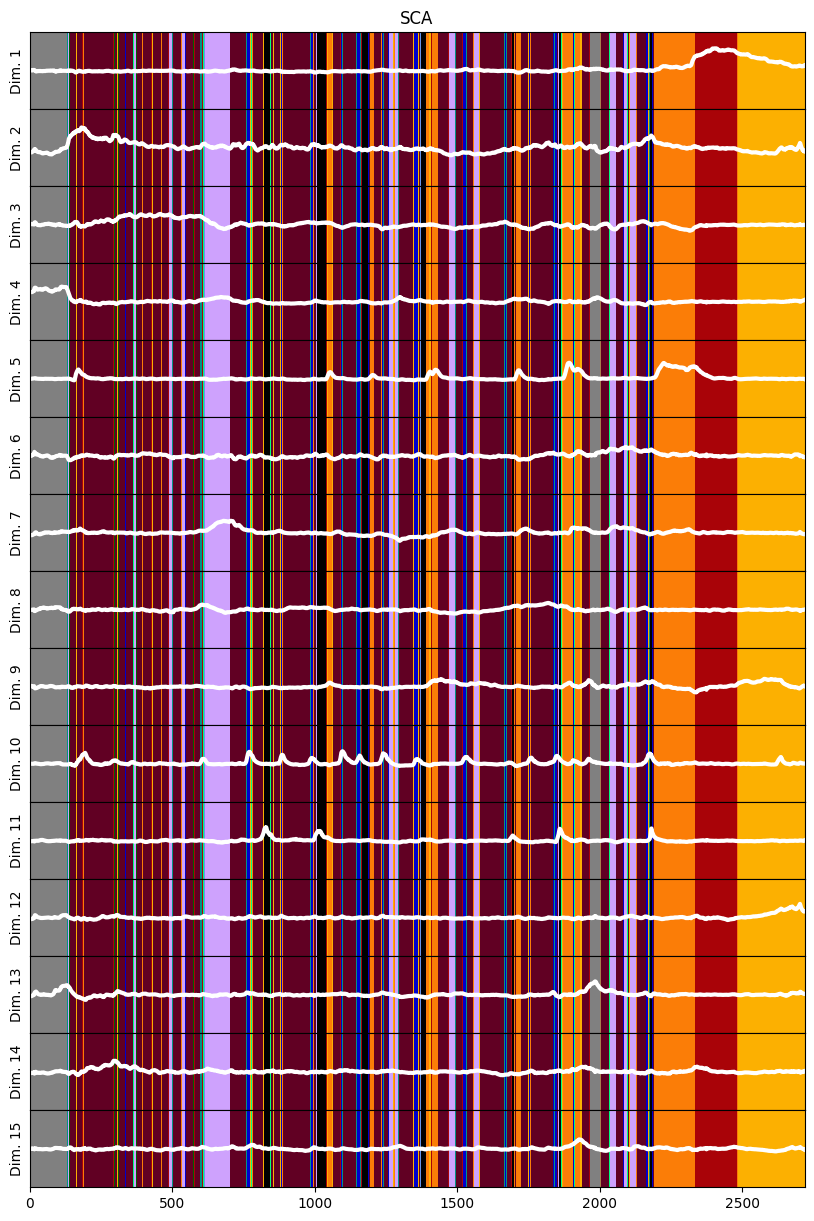

In [14]:
## Plot SCA results

# sub directory for figures
subDir = figDir + 'SCA_PCA_plots/'

# plotting parameters
cLimit = [1,13]
yLimit = [-0.5, 0.5]
lineWidth = 3.0

# scale factor for traces
scaleFactor = 7

### cycle through worms
for ww in range(1): # only plot the first worm

    # grab our sca and pca latents
    sca_latent = SCA_flip[ww]
    pca_latent = PCA_flip[ww]

    # time duration
    T=sca_latent.shape[0]

    # which worm are we working with?
    wormID = goodIDs[ww]

    # initialize a figure
    fig,ax=plt.subplots(R_est,1,figsize=(10,15))

    for i in range(R_est):

        ax[i].imshow(data[data['Dataset']==wormID]['Ethogram'][:,None].T,aspect='auto',clim=cLimit,cmap=colormap,alpha=alpha)
        ax[i].plot(sca_latent[:,i]/scaleFactor,linewidth=lineWidth,color='white')


        ax[i].set_xlim([0,T])
        ax[i].set_ylim(yLimit)

        if i<R_est-1:
            ax[i].set_xticks([])


        ax[i].set_yticks([])
        ax[i].set_ylabel('Dim. '+str(i+1))
        ax[i].grid(False)
        ax[0].set_title('SCA')
        plt.subplots_adjust(hspace=0);


    # # save figure
    # plt.savefig(subDir + 'worm_' + str(wormID) + '.svg', dpi=1000, format='svg', bbox_inches='tight' )
    # plt.close()

### Plot the loading matrix for each worm

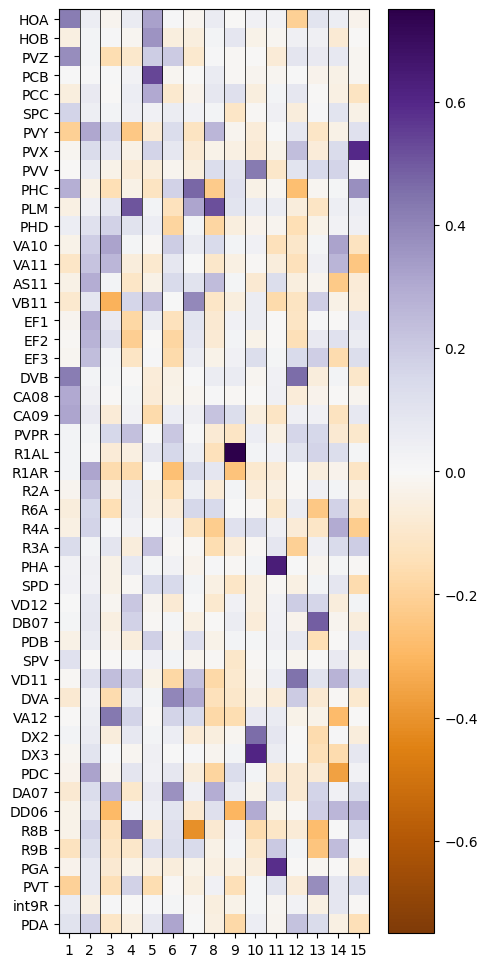

In [15]:
# sub-directory
subDir = figDir + 'scaLoadingMatrices/'

# cycle through  worms
for ii in range(1): # only plot the first worm
    wormID = goodIDs[ii]

    neur_names=list(np.array(data.columns[1:59])[~np.isnan(data.iloc[:,1:59][data['Dataset']==wormID]).iloc[0,:]])
    plt.figure(figsize=(5,12))

    # plot loadings (remembering to flip the loadings corresponding to the flipped dimensions
    plt.imshow(SCA_loadings[ii] * scaFlips[ii],aspect='auto',cmap='PuOr',clim=[-0.75,0.75])
    plt.yticks(range(len(neur_names)),labels=neur_names)
    plt.xticks(range(R_est),np.arange(1,R_est+1))

    # get rid of grid
    ax=plt.gca()
    ax.grid(False);

    # plot a more useful grid
    vLineLoc = np.arange(0.5,R_est+0.5,1)
    hLineLoc = np.arange(-0.5,len(neur_names)-0.5,1)
    plt.vlines(vLineLoc,-0.5,len(neur_names)-0.5,colors='black',linewidth=0.5);
    plt.colorbar()

    # # save matrix
    # plt.savefig(subDir + 'worm_' + str(wormID) + '.pdf', dpi=1000,format='pdf')
    # plt.close()

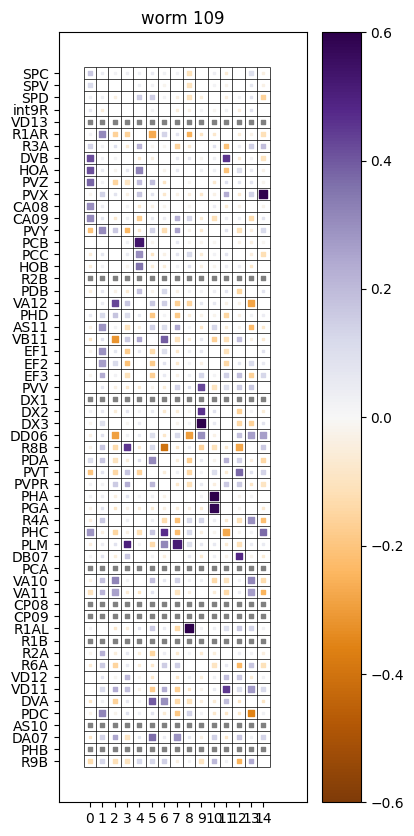

In [18]:
# rather than plotting individual columns, generate an N x K matrix of all of the loadings for an individual worm

# generate a colormap
from matplotlib import colormaps
from matplotlib.colors import Normalize
cmap = colormaps['PuOr']
cmap.set_bad(color=[0.5,0.5,0.5],alpha=1)

# multiplier for the size of the square
mSizeMult = 50

# transparency multiplier
aNorm = Normalize(vmin=0, vmax=0.85)

# color limits for plots
cLimit = [-0.6, 0.6]
cNorm = Normalize(vmin=cLimit[0], vmax=cLimit[1])

# names for all neurons
neur_names = data.columns[1:59].to_list()

# change the order of the names
neur_names = [neur_names[x] for x in neuronOrder]

# number of neurons
numN = len(neur_names)

# size of the figure
fSize = (4,10)

for ww in range(1): # only plot the first worm

    # worm ID
    wormID = goodIDs[ww]

    # subdirectory for these figs
    subDir = figDir + 'scaLoadingMatrices/'

    # grab our loadings
    loadings = SCA_loadings[ww] * scaFlips[ww]

    # get the indices for the neurons that are present in this dataset
    isNeuronHere = ~np.isnan(data.iloc[:,1:59][data.Dataset==wormID]).to_numpy()[0,:]
    neuronIdx = np.argwhere(isNeuronHere)[:,0]

    # second vector for the missing values
    emptyIdx = np.argwhere(~isNeuronHere)[:,0]

    # set up figure
    plt.figure(figsize=fSize)

    # cyle through all dimensions and plot
    for ii in range(R_est):


        # plot loadings
        # initialize vector that is 58 elements long, plug in weights
        l = np.zeros((58)) + np.nan
        l[neuronIdx] = loadings[:,ii]

        # change to the correct plotting order
        l = l[neuronOrder]

        # plot
        for jj in range(numN):
            if ~np.isnan(l[jj]):
                plt.scatter(ii,numN-jj-1,s=abs(l[jj])*mSizeMult, color=cmap(cNorm(l[jj])), marker='s');
            else:
                plt.scatter(ii,numN-jj-1,s=10, color=cmap(np.nan), marker='s');


    # get rid of grid
    ax=plt.gca()
    plt.set_cmap('PuOr');
    plt.clim(cLimit);

    ax.grid(False);

    # plot a more useful grid
    vLineLoc = np.arange(-0.5,R_est+0.5,1)
    hLineLoc = np.arange(-0.5,len(neur_names),1)
    plt.vlines(vLineLoc,-0.5,len(neur_names)-0.5,colors='black',linewidth=0.5);
    plt.hlines(hLineLoc,-0.5,R_est-0.5,colors='black',linewidth=0.5);
    plt.colorbar()

    plt.xlim([-2.5,R_est + 2.5]);

    # add title
    plt.title('worm ' + str(wormID))

    # add tick marks
    plt.yticks(range(len(neur_names)),labels=neur_names[::-1])
    plt.xticks(range(R_est),list(range(R_est)))

    # # save figure
    # plt.savefig(subDir + 'worm_' + str(wormID) + 'allLoadings.pdf', dpi=1000,format='pdf')
    # plt.close()

### For each dimension of each worm, calculate an 'event triggered average' and an 'event trigger change' to determine how likely a given dimension is to relate to a particular behavior

In [ ]:
# import a function for fitting a gaussian distribution
from scipy.stats import norm

# window around event to use for analysis
periEventWindow = np.arange(-5,30)
windowDur = periEventWindow.shape[0]

# min and max of periEvent window
windowMin = np.abs(periEventWindow[0])
windowMax = periEventWindow[-1]

# statistical threshold for determining if a latent is related to a behavior
pThresh = 0.95

# how long does a trace need to be above threshold to be considered significant? (in number of samples)
durThresh = 1

# number of samples to use to calculate baseline distribution
numCntrls = 2000

# number of behaviors
numBehaviors = 13

# minimum number of samples between repetitions of the same behavior
minSamplesBetweenReps = 30

# list to hold minimum pValues for every behavior/latent/worm
behP = []

# list of all of the etas
ETA_avg = []
ETA_delta = []

# list of all of the significance thresholds
SIGTHRESH_avg = []
SIGTHRESH_delta = []

# loop through worms
for ww in range(numWorms):

    # ID for this worm
    wormId = goodIDs[ww]


    # ethogram for this worm
    eth = data.Ethogram[data.Dataset==wormId].to_numpy()

    # trim ethogram by 1 sample to match size of dLatent below
    eth = eth[1:]

    # trial duration
    trlDur = eth.shape[0]

    # initialize a matrix of length numBehaviors (shape[1] = R_est) to hold minimum P value
    minP = np.zeros((numBehaviors,R_est)) + np.nan

    # windowDur x R_est x number of behaviors matrix to save the eta and significance thresholds
    tempETA_avg    = np.zeros((windowDur, R_est, numBehaviors)) + np.nan
    tempThresh_avg = np.zeros((windowDur, R_est, numBehaviors)) + np.nan
    tempETA_delta    = np.zeros((windowDur, R_est, numBehaviors)) + np.nan
    tempThresh_delta = np.zeros((windowDur, R_est, numBehaviors)) + np.nan

    # loop through latents
    for ss in range(R_est):

        # sca latent for this worm
        sca_latent = SCA_flip[ww][:,ss]
        latent = sca_latent[1:]

        # temporal derivative of signal
        dLatent = np.diff(sca_latent)

        # generate 'numCntrls' random time points to use to generate a control distribution for this latent
        cntrlTimes = np.random.choice(np.arange(windowMin,trlDur-windowMax), size=numCntrls, replace=True)

        # generate the control distribution from the cntrlTimes
        cntrlSamps_avg = np.zeros((numCntrls,windowDur))
        cntrlSamps_delta = np.zeros((numCntrls,windowDur))
        for ii in range(numCntrls):
            cntrlSamps_delta[ii,:] = dLatent[cntrlTimes[ii]+periEventWindow]
            cntrlSamps_avg[ii,:]   = latent[cntrlTimes[ii]+periEventWindow]


        # fit a gaussian to every time, calculate the 'pThresh' threshold
        cntlMean_avg = np.zeros(windowDur)
        cntlStd_avg  = np.zeros(windowDur)
        sigThresh_avg = np.zeros(windowDur)
        cntlMean_delta = np.zeros(windowDur)
        cntlStd_delta  = np.zeros(windowDur)
        sigThresh_delta = np.zeros(windowDur)

        for ii in range(windowDur):

            cntlMean_delta[ii],cntlStd_delta[ii] = norm.fit(cntrlSamps_delta[:,ii])
            sigThresh_delta[ii] = norm.ppf(pThresh,loc=cntlMean_delta[ii],scale=cntlStd_delta[ii])

            cntlMean_avg[ii],cntlStd_avg[ii] = norm.fit(cntrlSamps_avg[:,ii])
            sigThresh_avg[ii] = norm.ppf(pThresh,loc=cntlMean_avg[ii],scale=cntlStd_avg[ii])


        ### cycle through behaviors, calculating the event triggered average for each
        for bb in range(numBehaviors):


            # boolean vector of where this behavior occurs
            behIdx = (eth==(bb+1)).astype(int)

            # only continue if this behavior occurs
            if np.sum(behIdx) > 0:

                # index where this behavior starts

                # see if the trial starts with this behavior
                if behIdx[0] == 1:
                    startIdx = np.array([0])
                else:
                    startIdx = np.array([])

                # now see where else this behavior occurs
                diffIdx = np.diff(behIdx)
                startIdx2 = np.nonzero(diffIdx == 1)[0] + 1
                startIdx = np.concatenate((startIdx,startIdx2)).astype(int)

                # deal with 'flicker' in the ethogram. Occasionally, the classification will bounce back and forth between 2 behaviors at a timescale that's faster than the fluorescence can resolve. When this happens, remove all but the first startIdx.

                if startIdx.size > 1:

                    # calculate minimum duration between starts
                    minStart = np.min(np.diff(startIdx))
                    while (minStart < minSamplesBetweenReps) & (startIdx.size > 1):

                        # remove the shortest interval
                        startIdx = np.delete(startIdx,np.argmin(np.diff(startIdx))+1)

                        # recalculate our minimum duration
                        if startIdx.size>1:
                            minStart = np.min(np.diff(startIdx))


                # initialize a matrix to hold the single-event traces
                traces_delta = np.zeros((startIdx.shape[0],windowDur))
                traces_avg = np.zeros((startIdx.shape[0],windowDur))

                # plug in the traces
                for jj in range(startIdx.size):

                    # the event occurs near the end of the trial
                    if startIdx[jj] > (trlDur - windowMax):

                        # duration of this trace
                        traceDur = (trlDur - startIdx[jj]) + windowMin
                        traces_delta[jj,:traceDur] = dLatent[(startIdx[jj]-windowMin):]
                        traces_avg[jj,:traceDur] = latent[(startIdx[jj]-windowMin):]

                    # the event occurs near the start of the trial
                    elif startIdx[jj] < windowMin:

                        traces_delta[jj,(windowMin-startIdx[jj]+1):] = dLatent[:(startIdx[jj] + windowMax)]
                        traces_avg[jj,(windowMin-startIdx[jj]+1):]   = latent[:(startIdx[jj] + windowMax)]

                    else:
                        traces_delta[jj,:] = dLatent[startIdx[jj]+periEventWindow]
                        traces_avg[jj,:]   = latent[startIdx[jj]+periEventWindow]

                # replace any remaining zeros with NaNs
                nanIdx = traces_avg==0
                traces_avg[nanIdx]   = np.nan
                traces_delta[nanIdx] = np.nan

                # calculate ETA
                eta_delta = np.nanmedian(traces_delta,axis=0)
                eta_avg = np.nanmedian(traces_avg,axis=0)

                # save eta
                tempETA_delta[:,ss,bb] = eta_delta
                tempETA_avg[:,ss,bb] = eta_avg

                # save significance threshold
                tempThresh_delta[:,ss,bb] = sigThresh_delta
                tempThresh_avg[:,ss,bb] = sigThresh_avg

                # find times where the eta is greater than the pThreshold
                isSig_delta = (eta_delta > sigThresh_delta).astype(int)
                isSig_avg = (eta_avg > sigThresh_avg).astype(int)



                if (np.sum(isSig_delta) >= durThresh) & (np.sum(isSig_avg) >= durThresh) :

                    # find the time where the difference between eta and the control distribution is the greatest
                    # use the average for this value
                    maxIdx = np.argmax(eta_avg - sigThresh_avg)

                    # calculate the p value at this time
                    minP[bb,ss] = 1 - norm.cdf(eta_avg[maxIdx],loc=cntlMean_avg[maxIdx],scale=cntlStd_avg[maxIdx])


    # add minP to our list
    behP.append(minP)

    # save etas and sig thresholds
    ETA_avg.append(tempETA_avg)
    ETA_delta.append(tempETA_delta)

    SIGTHRESH_avg.append(tempThresh_avg)
    SIGTHRESH_delta.append(tempThresh_delta)


In [20]:
# for each worm, determine which latents had statistically sig. responses to a given behavior

# behavior that we're interested in (0-indexed)
bIdx = 12

# cycle through the worms and print results
for ww in range(numWorms):

    # pull out the p values for this worm (numBehaviors x R_est)
    beh = behP[ww]

    # find the dimensions that have sig. values for the given behavior (not NaNs)
    goodIdx = np.nonzero(~np.isnan(beh[bIdx,:]))

    # return the indices
    display('worm ' + str(goodIDs[ww]) + ': dims. ' + str(goodIdx))

'worm 109: dims. (array([10]),)'

'worm 137: dims. (array([ 0,  7, 11]),)'

'worm 153: dims. (array([2, 6, 9]),)'

'worm 182: dims. (array([12]),)'

'worm 184: dims. (array([], dtype=int64),)'

'worm 185: dims. (array([], dtype=int64),)'

'worm 714: dims. (array([], dtype=int64),)'

'worm 2457: dims. (array([1, 5]),)'

### Generalization analysis

In [ ]:
import scipy.signal
# Correlate each latent (SCA and PCA) with a (filtered) vector of behavior

# first, define our filtering kernel (gamma function)
# shape parameter
alpha = 2

# location and scale parameters
loc = 0
scale = 5

# size of kernel
kernelL = 100

# define our kernel
kernel = scipy.stats.gamma.pdf(np.arange(-kernelL,kernelL),alpha, loc=loc, scale=scale)
kernel = kernel/np.sum(kernel)

# behaviors to use in this analysis
behaviors = np.arange(1,14)
numBehaviors = behaviors.size

# array to hold correlation for each worm
worm1_corr_sca = np.zeros((numWorms,R_est,numBehaviors)) + np.nan
worm1_corr_pca = np.zeros((numWorms,R_est,numBehaviors)) + np.nan

# take the weights (SCA and PCA) from worm1, generate new latents using the activity from worm2, correlate new latents with behavior of worm 2
worm2_corr_sca = np.zeros((numWorms, numWorms, R_est, numBehaviors)) + np.nan
worm2_corr_pca = np.zeros((numWorms, numWorms, R_est, numBehaviors)) + np.nan

# save vectors of worm1 behavior and the pseudolatents from worm2
worm1_behavior = np.zeros((numWorms,numBehaviors,3000)) + np.nan
worm2_pseudoLatents = np.zeros((numWorms,numWorms,R_est,3000)) + np.nan

## cycle through worm 1
for w1 in range(numWorms):

    # id for worm 1
    worm1_ID = goodIDs[w1]

    # index for worm1
    worm1_idx = goodIDs.index(worm1_ID)

    # ethogram for worm 1
    eth1 = data.Ethogram[data.Dataset==worm1_ID].to_numpy()


    # grab the sca and pca latents
    worm1_latents_sca = SCA_latents[worm1_idx]
    worm1_latents_pca = PCA_latents[worm1_idx]

    # get a list of worm 2's
    worm2_list = goodIDs.copy()
    worm2_list.pop(w1)

    # silly index that will be useful later
    sillyIdx = np.arange(numWorms)
    sillyIdx = np.delete(sillyIdx,w1)

    # which neurons are present in worm1?
    worm1_neuronHere = ~np.isnan(data.iloc[:,1:59][data.Dataset==worm1_ID]).to_numpy()[0,:]
    worm1_neuronIdx = np.argwhere(worm1_neuronHere)[:,0]

    # grab the sca and pca weights from worm1
    worm1_original_weights_sca = SCA_loadings[worm1_idx]
    worm1_original_weights_pca = PCA_loadings[worm1_idx]

    # make a vector that is size (maxNeurons x R_est) and plug in the weights
    worm1_weights_sca = np.zeros((58,R_est))
    worm1_weights_sca[worm1_neuronIdx,:] = worm1_original_weights_sca

    # do the same for the PCA weights
    worm1_weights_pca = np.zeros((58,R_est))
    worm1_weights_pca[worm1_neuronIdx,:] = worm1_original_weights_pca

    # cycle through behaviors
    for idx, bb in enumerate(behaviors):

        # convert the ethogram into boolean vectors that indicate when the behavior we care about occurred
        beh1 = (np.isin(eth1,bb)).astype('int')

        # save this behavior
        behL = beh1.size
        worm1_behavior[w1,idx,:behL] = beh1

        # convolve
        beh1_conv = scipy.signal.convolve(beh1,kernel,'same')

        if np.any(np.isnan(beh1_conv)):
            print(str(w1) + ' ' + str(idx) + ' ')

        # calculate correlations
        for ii in np.arange(R_est):
            worm1_corr_sca[w1,ii,idx] = np.abs(np.corrcoef(beh1_conv,worm1_latents_sca[:,ii])[0,1])
            worm1_corr_pca[w1,ii,idx] = np.abs(np.corrcoef(beh1_conv,worm1_latents_pca[:,ii])[0,1])

        # cycle through worm 2's
        for w2 in range(len(worm2_list)):

            # id for worm 2
            worm2_ID = worm2_list[w2]

            # index for worm2
            worm2_idx = goodIDs.index(worm2_ID)

            # ethogram for worm 2
            eth2 = data.Ethogram[data.Dataset==worm2_ID].to_numpy()

            # convert the ethogram into boolean vectors that indicate when the behavior we care about occured
            beh2 = (np.isin(eth2,bb)).astype('int')

            # convolve
            beh2_conv = scipy.signal.convolve(beh2,kernel,'same')

            # generate latents for worm 2 using the weights from worm 1
            worm2_rates  = data.iloc[:,1:59][data['Dataset']==worm2_ID].to_numpy()

            # replace NaNs with zeros
            worm2_rates[np.isnan(worm2_rates)] = 0

            # normalize each rate by its range
            worm2_rates_norm = worm2_rates / np.ptp(worm2_rates,axis=0)

            # replace the nan's we get above when we divide by 0 with zeros
            worm2_rates_norm[np.isnan(worm2_rates_norm)] = 0

            # generate latents for worm2
            worm2_latents_sca = worm2_rates_norm @ worm1_weights_sca
            worm2_latents_pca = worm2_rates_norm @ worm1_weights_pca

            # save these latents
            latL = worm2_latents_sca.shape[0]
            worm2_pseudoLatents[w1,sillyIdx[w2],:,:latL] = worm2_latents_sca.T

            # cycle through latents, calculating correlations
            for ii in np.arange(R_est):
                worm2_corr_sca[w1,sillyIdx[w2],ii,idx] = np.abs(np.corrcoef(beh2_conv,worm2_latents_sca[:,ii])[0,1])
                worm2_corr_pca[w1,sillyIdx[w2],ii,idx] = np.abs(np.corrcoef(beh2_conv,worm2_latents_pca[:,ii])[0,1])

In [40]:
M = worm1_corr_sca[0,:,:]
motifHere = ~np.isnan(M[0,:])
z = [titles[x] for x,y in enumerate(motifHere) if y]
print(z)

['1: Searching (not in contact w/ hermaph)', '3: Scanning', '4: Resting (in contact w/ hermaph)', '5: Stopping at vulva (before sperm release)', '6: Stopping at vulva (after sperm release)', '7: Unsuccessful turning, before sperm release', '8: Turning, before sperm release', '12: forward sliding', '13: excretory pore detection']


In [41]:
titles

['1: Searching (not in contact w/ hermaph)',
 '2: Resting (not in contact w/ hermaph)',
 '3: Scanning',
 '4: Resting (in contact w/ hermaph)',
 '5: Stopping at vulva (before sperm release)',
 '6: Stopping at vulva (after sperm release)',
 '7: Unsuccessful turning, before sperm release',
 '8: Turning, before sperm release',
 '9: Turning, after sperm release',
 '10: Self contact, before sperm release',
 '11: Self contact, after sperm release',
 '12: forward sliding',
 '13: excretory pore detection']

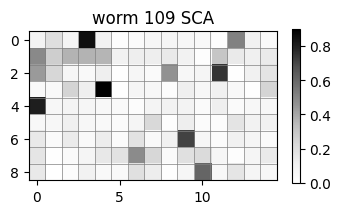

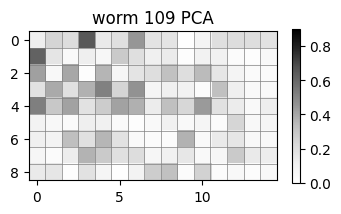

In [42]:
# for an example worm, generate a motif x factor correlation matrix

# generate a colormap
from matplotlib import colormaps
from matplotlib.colors import Normalize
cmap = colormaps['Greys']
cmap.set_bad(color=[1,0,0],alpha=1)


# color limits for plots
cLimit = [0, 0.9]
cNorm = Normalize(vmin=cLimit[0], vmax=cLimit[1])

# grab the matrix we want to plot
M_sca = worm1_corr_sca[0,:,:]
M_pca = worm1_corr_pca[0,:,:]

# throw out columns (motifs) that aren't here
M_sca = M_sca[:,~np.isnan(M_sca[0,:])]
fig = plt.figure(figsize=(4,2));
ax = fig.gca();
plt.imshow(M_sca.T,cmap=cmap,norm=None,vmin=0,vmax=cLimit[1],interpolation=None);
# add vertical and horizontal lines
plt.vlines(np.arange(-1.5,15.5),-0.5,8.5,colors=[0.5,0.5,0.5],lw=0.5);
plt.hlines(np.arange(-0.5,8.5),-0.5,14.5,colors=[0.5,0.5,0.5],lw=0.5);
plt.colorbar();
ax.grid(False);
ax.set_xlim([-0.5,14.5]);
plt.title('worm 109 SCA');
plt.show()
# # save figure
# plt.savefig(figDir + '/SCA_PCA_plots/worm1_neural_motif_corrMatrix_SCA.pdf' )

M_pca = M_pca[:,~np.isnan(M_pca[0,:])]
fig = plt.figure(figsize=(4,2));
ax = fig.gca();
plt.imshow(M_pca.T,cmap=cmap,norm=None,vmin=0,vmax=cLimit[1]);
# add vertical and horizontal lines
plt.vlines(np.arange(-1.5,15.5),-0.5,8.5,colors=[0.5,0.5,0.5],lw=0.5);
plt.hlines(np.arange(-0.5,8.5),-0.5,14.5,colors=[0.5,0.5,0.5],lw=0.5);
plt.colorbar();
ax.grid(False);
ax.set_xlim([-0.5,14.5]);
plt.title('worm 109 PCA');
plt.show()

# # save figure
# plt.savefig(figDir + '/SCA_PCA_plots/worm1_neural_motif_corrMatrix_PCA.pdf' )





SCA (mean and sem): 0.47264615211734445 0.019297925424272184
PCA (mean and sem): 0.3665782702905794 0.014767728533390768
p = 7.950030718252014e-05


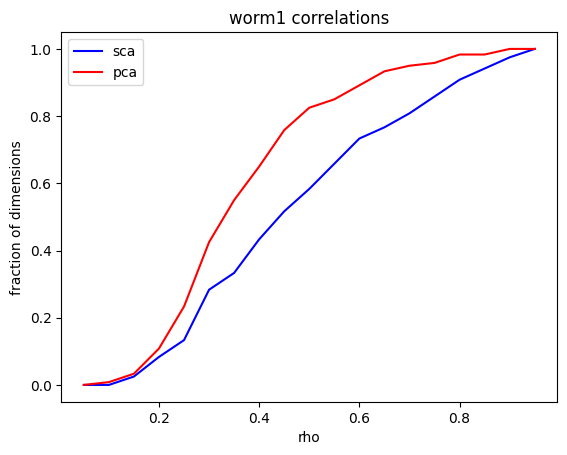

In [43]:
# for each latent, keep the maximum correlation, then plot the mean (and sem) across worms and latents
maxCorr_sca = np.nanmax(np.abs(worm1_corr_sca),axis=2).reshape(-1,1)[:,0]
maxCorr_pca = np.nanmax(np.abs(worm1_corr_pca),axis=2).reshape(-1,1)[:,0]

# calculate mean and std
sca_mean = np.mean(maxCorr_sca)
sca_sem  = np.std(maxCorr_sca) / np.sqrt(maxCorr_sca.size)
pca_mean = np.mean(maxCorr_pca)
pca_sem  = np.std(maxCorr_pca) / np.sqrt(maxCorr_pca.size)

# print results
print('SCA (mean and sem): ' + str(sca_mean) + ' ' + str(sca_sem))
print('PCA (mean and sem): ' + str(pca_mean) + ' ' + str(pca_sem))

# plot
bins = np.arange(0,1,0.05)
binCenters = (np.arange(bins[0]+0.05,bins[-1]+0.05,0.05))
scaHist,edges = np.histogram(maxCorr_sca,bins)
pcaHist,edges = np.histogram(maxCorr_pca,bins)


scaHist = scaHist / sum(scaHist)
pcaHist = pcaHist / sum(pcaHist)
sca_cumSum = np.cumsum(scaHist)
pca_cumSum = np.cumsum(pcaHist)
plt.plot(binCenters,sca_cumSum,'b',label = 'sca');
plt.plot(binCenters,pca_cumSum,'r',label='pca');
plt.legend()

# add some labels
plt.xlabel('rho')
plt.ylabel('fraction of dimensions')
plt.title('worm1 correlations');


# perform rank sum test on sca and pca results (are the means of the distribution different?)
res_test = scipy.stats.ranksums(maxCorr_sca,maxCorr_pca)
print('p = ' + str(res_test.pvalue))

SCA (non-normalized) (mean and sem): 0.3358756208158083 0.00865244971057686
PCA (non-normalized) (mean and sem): 0.28697134510669586 0.007699274981144281
p = 0.00018230168347663355


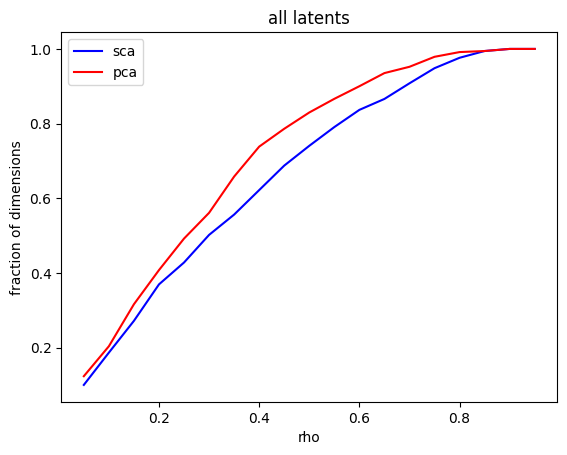

In [45]:
# get some numbers from across worms

# for each latent and each worm, find the behavior that that latent most corresponds to (and the correlation)
# ask how well the pseudo latent predicts that same behavior in a second worm

# get the max correlations for each worm1, and the behavioral indices
worm1_maxCorr_sca = np.nanmax(worm1_corr_sca,axis=2)
worm1_maxCorr_pca = np.nanmax(worm1_corr_pca,axis=2)

# get the index where these maxes occur
worm1_maxCorrIdx_sca = np.nanargmax(worm1_corr_sca,axis=2)
worm1_maxCorrIdx_pca = np.nanargmax(worm1_corr_pca,axis=2)

# initialize a numWorms x (numWorms) x R_est tensor to hold the corresponding rhos for all worm 2's
# note that one slice of the second dimension will just be NaN's (each worm1 has 7 worm comparisons). Doing it this way just made indexing easier.
worm2_maxCorr_sca = np.zeros((numWorms,numWorms,R_est)) + np.nan
worm2_maxCorr_pca = np.zeros((numWorms,numWorms,R_est)) + np.nan

# cycle through worm1's
for w1 in range(numWorms):

    # cycle through dimensions
    for dd in range(R_est):

        # grab the behavioral index that we need
        bIdx_sca = worm1_maxCorrIdx_sca[w1,dd]
        bIdx_pca = worm1_maxCorrIdx_pca[w1,dd]

        # grab the relevant slices
        worm2_maxCorr_sca[w1,:,dd] = worm2_corr_sca[w1,:,dd,bIdx_sca]
        worm2_maxCorr_pca[w1,:,dd] = worm2_corr_pca[w1,:,dd,bIdx_pca]

# reshape and throw away NaNs (worm2 might not have the worm1 behavior)
worm2_sca_rs = worm2_maxCorr_sca.reshape(-1,1,order='F')[:,0]
worm2_pca_rs = worm2_maxCorr_pca.reshape(-1,1,order='F')[:,0]

worm2_sca_rs = worm2_sca_rs[~np.isnan(worm2_sca_rs)]
worm2_pca_rs = worm2_pca_rs[~np.isnan(worm2_pca_rs)]

# calculate mean and std
sca_mean = np.mean(worm2_sca_rs)
sca_sem  = np.std(worm2_sca_rs) / np.sqrt(worm2_sca_rs.size)
pca_mean = np.mean(worm2_pca_rs)
pca_sem  = np.std(worm2_pca_rs) / np.sqrt(worm2_pca_rs.size)

# print results
print('SCA (non-normalized) (mean and sem): ' + str(sca_mean) + ' ' + str(sca_sem))
print('PCA (non-normalized) (mean and sem): ' + str(pca_mean) + ' ' + str(pca_sem))

# plot distributions
bins = np.arange(0,1,0.05)
binCenters = (np.arange(bins[0]+0.05,bins[-1]+0.05,0.05))
scaHist,edges = np.histogram(worm2_sca_rs,bins)
pcaHist,edges = np.histogram(worm2_pca_rs,bins)

scaHist = scaHist / sum(scaHist)
pcaHist = pcaHist / sum(pcaHist)
sca_cumSum = np.cumsum(scaHist)
pca_cumSum = np.cumsum(pcaHist)
plt.plot(binCenters,sca_cumSum,'b',label = 'sca');
plt.plot(binCenters,pca_cumSum,'r',label='pca');
plt.legend()

# add some labels
plt.xlabel('rho')
plt.ylabel('fraction of dimensions')
plt.title('all latents');

# calculate significance
res_test = scipy.stats.ranksums(worm2_sca_rs,worm2_pca_rs)
print('p = ' + str(res_test.pvalue))



SCA (non-normalized) (mean and sem): 0.47590044499674156 0.01743877702476675
PCA (non-normalized) (mean and sem): 0.3948398505276747 0.01624517805258866
raw: p = 0.0006253572109393153
normalized: p = 0.31294219937644585


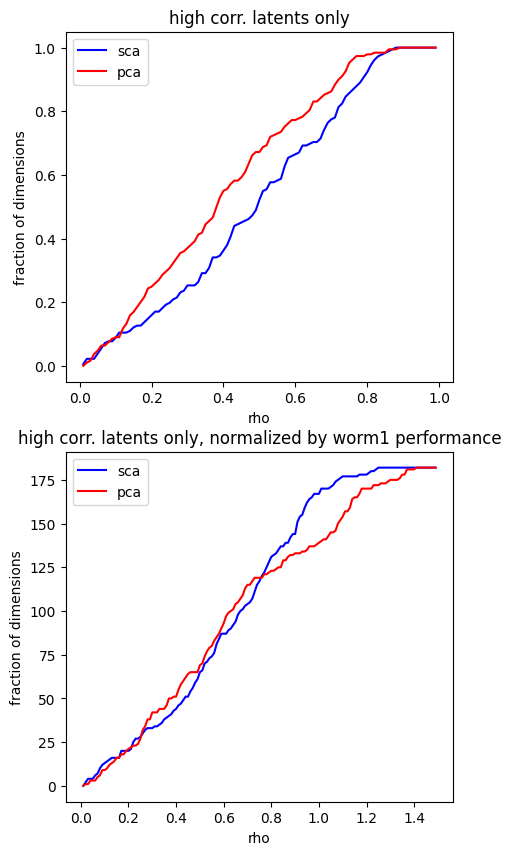

In [47]:
# re-do the analysis above, but only include latents where the worm1 correlations were especially high

# threshold for including a worm1 latent
pTile_cutoff = 75

# calculate the relevant percentiles
worm1_pTile_sca = np.percentile(np.nanmax(np.abs(worm1_corr_sca),axis=2).reshape(-1,1),pTile_cutoff)
worm1_pTile_pca = np.percentile(np.nanmax(np.abs(worm1_corr_pca),axis=2).reshape(-1,1),pTile_cutoff)

# for each latent and each worm, find the behavior that that latent most corresponds to (and the correlation)
# ask how well the pseudo latent predicts that same behavior in a second worm

# get the max correlations for each worm1, and the behavioral indices
worm1_maxCorr_sca = np.nanmax(np.abs(worm1_corr_sca),axis=2)
worm1_maxCorr_pca = np.nanmax(np.abs(worm1_corr_pca),axis=2)

# get the index where these maxes occur
worm1_maxCorrIdx_sca = np.nanargmax(np.abs(worm1_corr_sca),axis=2)
worm1_maxCorrIdx_pca = np.nanargmax(np.abs(worm1_corr_pca),axis=2)

# throw out values below the cutoff
lowIdx_sca = worm1_maxCorr_sca < worm1_pTile_sca
lowIdx_pca = worm1_maxCorr_pca < worm1_pTile_pca

worm1_maxCorr_sca[lowIdx_sca] = -99
worm1_maxCorrIdx_sca[lowIdx_sca] = -99
worm1_maxCorr_pca[lowIdx_pca] = -99
worm1_maxCorrIdx_pca[lowIdx_pca] = -99


# initialize a numWorms x (numWorms) x R_est tensor to hold the corresponding rhos for all worm 2's
# note that one slice of the second dimension will just be NaN's (each worm1 has 7 worm comparisons). Doing it this way just made indexing easier.
worm2_maxCorr_sca = np.zeros((numWorms,numWorms,R_est)) + np.nan
worm2_maxCorr_pca = np.zeros((numWorms,numWorms,R_est)) + np.nan

# also save normalized worm2 values (how well are we doing compared to worm1 performance?)
worm2_maxCorr_norm_sca = np.zeros((numWorms,numWorms,R_est)) + np.nan
worm2_maxCorr_norm_pca = np.zeros((numWorms,numWorms,R_est)) + np.nan

# cycle through worm1's
for w1 in range(numWorms):

    # cycle through dimensions
    for dd in range(R_est):

        # grab the behavioral index that we need
        bIdx_sca = worm1_maxCorrIdx_sca[w1,dd]
        bIdx_pca = worm1_maxCorrIdx_pca[w1,dd]

        # and the worm1 correlation
        norm_corr_sca = worm1_maxCorr_sca[w1,dd]
        norm_corr_pca = worm1_maxCorr_pca[w1,dd]

        # grab the relevant slices
        if bIdx_sca>-1:
            worm2_maxCorr_sca[w1,:,dd] = worm2_corr_sca[w1,:,dd,bIdx_sca]
            worm2_maxCorr_norm_sca[w1,:,dd] = np.copy(worm2_maxCorr_sca[w1,:,dd]) / norm_corr_sca

        if bIdx_pca>-1:
            worm2_maxCorr_pca[w1,:,dd] = worm2_corr_pca[w1,:,dd,bIdx_pca]
            worm2_maxCorr_norm_pca[w1,:,dd] = np.copy(worm2_maxCorr_pca[w1,:,dd]) / norm_corr_pca


# reshape and throw away NaNs (worm2 might not have the worm1 behavior)
worm2_sca_rs = worm2_maxCorr_sca.reshape(-1,1,order='F')[:,0]
worm2_pca_rs = worm2_maxCorr_pca.reshape(-1,1,order='F')[:,0]

worm2_sca_rs = worm2_sca_rs[~np.isnan(worm2_sca_rs)]
worm2_pca_rs = worm2_pca_rs[~np.isnan(worm2_pca_rs)]

worm2_sca_norm_rs = worm2_maxCorr_norm_sca.reshape(-1,1,order='F')[:,0]
worm2_pca_norm_rs = worm2_maxCorr_norm_pca.reshape(-1,1,order='F')[:,0]

worm2_sca_norm_rs = worm2_sca_norm_rs[~np.isnan(worm2_sca_norm_rs)]
worm2_pca_norm_rs = worm2_pca_norm_rs[~np.isnan(worm2_pca_norm_rs)]

# calculate mean and std
sca_mean = np.mean(worm2_sca_rs)
sca_sem  = np.std(worm2_sca_rs) / np.sqrt(worm2_sca_rs.size)
pca_mean = np.mean(worm2_pca_rs)
pca_sem  = np.std(worm2_pca_rs) / np.sqrt(worm2_pca_rs.size)

# print results
print('SCA (non-normalized) (mean and sem): ' + str(sca_mean) + ' ' + str(sca_sem))
print('PCA (non-normalized) (mean and sem): ' + str(pca_mean) + ' ' + str(pca_sem))


# plot distributions
plt.figure(figsize=(5,10));
plt.subplot(2,1,1);
bins = np.arange(0,1,0.01)
binCenters = (np.arange(bins[0]+0.01,bins[-1]+0.01,0.01))
scaHist,edges = np.histogram(worm2_sca_rs,bins)
pcaHist,edges = np.histogram(worm2_pca_rs,bins)

scaHist = scaHist / sum(scaHist)
pcaHist = pcaHist / sum(pcaHist)
sca_cumSum = np.cumsum(scaHist)
pca_cumSum = np.cumsum(pcaHist)
plt.plot(binCenters,sca_cumSum,'b',label = 'sca');
plt.plot(binCenters,pca_cumSum,'r',label='pca');
plt.legend()

# add some labels
plt.xlabel('rho')
plt.ylabel('fraction of dimensions')
plt.title('high corr. latents only');

# plot distributions
plt.subplot(2,1,2);
bins = np.arange(0,1.5,0.01)
binCenters = (np.arange(bins[0]+0.01,bins[-1]+0.01,0.01))
scaHist_norm,edges = np.histogram(worm2_sca_norm_rs,bins)
pcaHist_norm,edges = np.histogram(worm2_pca_norm_rs,bins)

scaHist_norm = scaHist_norm / sum(scaHist)
pcaHist_norm = pcaHist_norm / sum(pcaHist)
sca_cumSum_norm = np.cumsum(scaHist_norm)
pca_cumSum_norm = np.cumsum(pcaHist_norm)
plt.plot(binCenters,sca_cumSum_norm,'b',label = 'sca');
plt.plot(binCenters,pca_cumSum_norm,'r',label='pca');
plt.legend()

# add some labels
plt.xlabel('rho')
plt.ylabel('fraction of dimensions')
plt.title('high corr. latents only, normalized by worm1 performance');

# calculate significance
res_test = scipy.stats.ranksums(worm2_sca_rs,worm2_pca_rs)
print('raw: p = ' + str(res_test.pvalue))
res_test_norm = scipy.stats.ranksums(worm2_sca_norm_rs,worm2_pca_norm_rs)
print('normalized: p = ' + str(res_test_norm.pvalue))

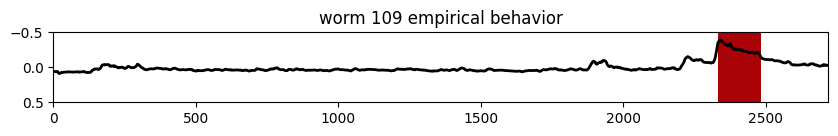

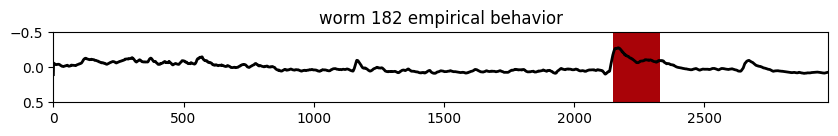

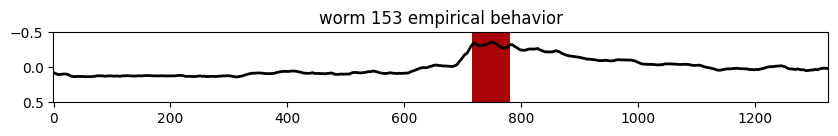

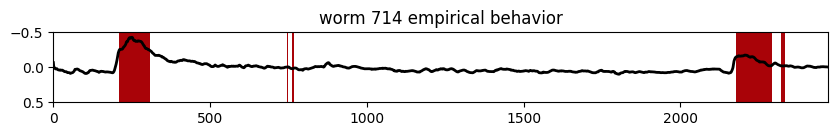

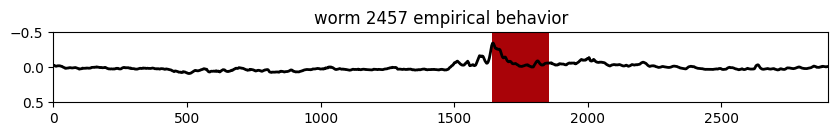

In [49]:
### make plots of actual worm2 behavior vs. worm2 pseudolatents
# set up a colormap that will be more useful
subDir = figDir + 'pseudoLatents/'
colormap2 = ListedColormap(
    ['white', 'xkcd:tan brown', 'xkcd:burgundy', 'xkcd:yellow orange', 'xkcd:pumpkin orange', 'xkcd:darkish red',
     'xkcd:teal',
     'mediumblue', 'cornflowerblue', 'darkgreen', 'springgreen', 'xkcd:lilac', 'black'], name='cMap')

# behavior we want to plot
behIdx = 5

# worm we want to use as the 'worm1' (i.e., the worm that we used to train the decoder
worm1Idx = 4

# index for the weights from worm1 that we want to use to predict worm2 behavior
latentIdx = 9

# worms we want to use as 'worm2s' (i.e., the worms whose behavior we are predicting)
worm2Idx = [0,3,2,6,7]

# how much to scale the pseudolatent
scaleFactor = 4

# cycle through worm2's
for w2 in worm2Idx:

    # grab worm 2 (actual) behavior. (sorry for the variable names, they are confusing. 'worm1_behavior' just means the actual behavior of each worm
    worm2Beh = worm1_behavior[w2,behIdx,:]

    # trim the NaNs
    worm2Beh = worm2Beh[~np.isnan(worm2Beh)]

    # length of worm 2 behavior
    behL = worm2Beh.size

    # grab the relevant pseudolatent
    worm2_pLatent = worm2_pseudoLatents[worm1Idx,w2,latentIdx,:behL]

    # initialize a figure
    fig = plt.figure(figsize=(10,2))

    # plot the actual behavior
    plt.subplot(2,1,1);
    plt.imshow(worm2Beh[np.newaxis,:]*(behIdx+1),cmap=colormap2,aspect='auto',clim=[1,13],interpolation='none');
    ax = plt.gca()
    ax.grid(False)
    plt.title('worm ' + str(goodIDs[w2]) + ' empirical behavior')

    # plot the pseudolatent
    plt.plot(worm2_pLatent/scaleFactor*-1,linewidth=2,color='black')


    # plt.savefig(subDir + 'pred_' + str(goodIDs[w2]) + '_from_' + str(goodIDs[worm1Idx]) + '_behavior_' + str(behIdx) +'_.pdf', dpi=500,format='pdf')
    # plt.close()
    plt.show()

In [50]:
# measure correlations between the pseudo latents and worm 2 behavior plotted in subpanel C

# behavior we want to plot
behIdx = 5

# worm we want to use as the 'worm1' (i.e., the worm that we used to train the decoder
worm1Idx = 4

# index for the weights from worm1 that we want to use to predict worm2 behavior
latentIdx = 9

# worms we want to use as 'worm2s' (i.e., the worms whose behavior we are predicting)
worm2Idx = [0,3,2,6,7]

# vector to hold correlations
allRho = np.zeros(len(worm2Idx))

# cycle through worm2's
for ii,w2 in enumerate(worm2Idx):

    # grab worm 2 (actual) behavior. (sorry for the variable names, they are confusing. 'worm1_behavior' just means the actual behavior of each worm
    worm2Beh = worm1_behavior[w2,behIdx,:]

    # trim the NaNs
    worm2Beh = worm2Beh[~np.isnan(worm2Beh)]

    # convolve (using the same kernel defined above)
    worm2Beh_conv =  scipy.signal.convolve(worm2Beh,kernel,'same')

    # length of worm 2 behavior
    behL = worm2Beh.size

    # grab the relevant pseudolatent
    worm2_pLatent = worm2_pseudoLatents[worm1Idx,w2,latentIdx,:behL]

    # calculate correlation
    allRho[ii] = np.corrcoef(worm2_pLatent,worm2Beh_conv)[0,1]

# print mean and std
print('mean rho: ' + str(np.mean(allRho)))
print('std rho: ' + str(np.std(allRho)))

mean rho: 0.5874415324921466
std rho: 0.1348354747716808


In [51]:
print(allRho)

[0.75935099 0.48789446 0.57997438 0.7119638  0.39802403]


In [52]:
# pull out the correlations between the pseudo factors generated from worm 1 and the neural activity from 5 other worm 2's, and the worm 2 copulation behavior
x = worm2_corr_sca[4,[0,3,2,6,7],9,5]
print(x)

[0.75935099 0.48789446 0.57997438 0.7119638  0.39802403]


In [53]:
# which neurons are present in worm1?
worm1_neuronHere = ~np.isnan(data.iloc[:,1:59][data.Dataset==worm1_ID]).to_numpy()[0,:]
worm1_neuronIdx = np.argwhere(worm1_neuronHere)[:,0]

In [54]:
# for each latent in each worm, find the single latent in a different worm that's most similar (in weight-space).
# repeat this process for 1-7 other worms. Do this to account for the fact that not all worms shared the same behaviors/neurons
# make all loadings for missing neurons 0

# make a single numWorm x numN x R_est tensor of sca and pca weights
SCA_W = np.zeros((numWorms,58,R_est))
PCA_W = np.zeros((numWorms,58,R_est))

for ii in range(numWorms):

    # figure out which neurons are here for this worm
    isNeuronHere = ~np.isnan(data.iloc[:,1:59][data.Dataset==goodIDs[ii]]).to_numpy()[0,:]
    neuronIdx = np.argwhere(isNeuronHere)[:,0]

    # plug in the known weights
    SCA_W[ii,neuronIdx,:] = SCA_loadings[ii]
    PCA_W[ii,neuronIdx,:] = PCA_loadings[ii]

# list to hold results
SCA_minAngle = [[] for x in range(7)]
PCA_minAngle = [[] for x in range(7)]

# cycle through worms
for ii in range(numWorms):

    # loadings for this worm
    scaLoadings1 = SCA_W[ii,:,:].squeeze()
    pcaLoadings1 = PCA_W[ii,:,:].squeeze()

    # indices for all other worms
    otherWormList = list(np.arange(numWorms))
    otherWormList.remove(ii)


    # cycle through all dimensions in worm 1
    for d1 in range(R_est):

        # initialize a list to hold angles between dim dd in worm 1 and all other angles in worm 2
        minWorm2Angle_sca = []
        minWorm2Angle_pca = []

        # cycle through worm2's
        for jj in otherWormList:

            # loadings for the second worms
            scaLoadings2 = SCA_W[jj,:,:].squeeze()
            pcaLoadings2 = PCA_W[jj,:,:].squeeze()

            # list to hold angle between worm1 dim and all worm2 dims
            worm2Angle_sca = []
            worm2Angle_pca = []

            # cycle through dimensions in worm 2
            for d2 in range(R_est):

                # worm1 dimension
                sca1 = scaLoadings1[:,d1]
                pca1 = pcaLoadings1[:,d1]

                # worm 2 dimension
                sca2 = scaLoadings2[:,d2]
                pca2 = pcaLoadings2[:,d2]

                # calculate angles
                sca_theta1 = np.arccos(np.dot(sca1,sca2) / (np.linalg.norm(sca1) * np.linalg.norm(sca2)) ) * (180/np.pi)
                pca_theta1 = np.arccos(np.dot(pca1,pca2) / (np.linalg.norm(pca1) * np.linalg.norm(pca2)) ) * (180/np.pi)

                sca_theta2 = np.arccos(np.dot(sca1*-1,sca2) / (np.linalg.norm(sca1) * np.linalg.norm(sca2)) ) * (180/np.pi)
                pca_theta2 = np.arccos(np.dot(pca1*-1,pca2) / (np.linalg.norm(pca1) * np.linalg.norm(pca2)) ) * (180/np.pi)


                # add to list
                worm2Angle_sca.append(np.min([sca_theta1, sca_theta2]))
                worm2Angle_pca.append(np.min([pca_theta1, pca_theta2]))

            # save the minimum angle
            minWorm2Angle_sca.append(np.min(worm2Angle_sca))
            minWorm2Angle_pca.append(np.min(worm2Angle_pca))

        # minWorm2Angle_sca is now 7 elements long. Sort this list, then add the lowest [1-7] angles to the nested list initialized in the top loop
        minWorm2Angle_sca.sort()
        minWorm2Angle_pca.sort()

        # cycle through number of comparisons
        for kk in range(7):
            SCA_minAngle[kk].append(np.mean(minWorm2Angle_sca[:(kk+1)]))
            PCA_minAngle[kk].append(np.mean(minWorm2Angle_pca[:(kk+1)]))


In [55]:
# plot results
# define sca and pca colors
eBarColors = ['#5e0044','#a79ba4']


# define some plotting parameters
eBarThickness = 3
eBarWidth = 5
markerSize = 5
markerLineWidth = 2

# initialize figure
fig = go.Figure()

# cycle through number of worms
for ii in range(len(SCA_minAngle)):


    # sca
    scaTrace = go.Scatter(
        x = [(ii*2)-0.1],y = [np.mean(SCA_minAngle[ii])],
        error_y = dict(
            type = 'data',
            array = [np.std(SCA_minAngle[ii])/np.sqrt(len(SCA_minAngle[ii]))],visible = True,thickness = eBarThickness,width = eBarWidth),
        marker = dict(
            color = eBarColors[0],
            size = markerSize,
            line = dict(
                color = 'black',
                width = markerLineWidth
            )
        ),showlegend = False
    )
    fig.add_trace(scaTrace)

    # pca
    pcaTrace = go.Scatter(
        x = [(ii*2)+0.1],y = [np.mean(PCA_minAngle[ii])],
        error_y = dict(
            type = 'data',
            array = [np.std(PCA_minAngle[ii])/np.sqrt(len(PCA_minAngle[ii]))],visible = True,thickness = eBarThickness,width = eBarWidth),
        marker = dict(
            color = eBarColors[1],
            size = markerSize,
            line = dict(
                color = 'black',
                width = markerLineWidth
            )
        ),showlegend = False
    )
    fig.add_trace(pcaTrace)


# clean up figure
fig.update_layout(height =500,width =600,title = 'loading similarity, all neurons',title_font_color = 'black',
                  paper_bgcolor = 'white',
                  plot_bgcolor = 'white')
fig.update_yaxes(showgrid = False,zeroline = False,visible = False)
fig.update_yaxes(color = 'black',ticks = 'outside',visible = True,showline = True,linewidth = 1.5,tickwidth = 1.5, title = ' mean angle (degrees)', range = [50,70] )
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,visible = False)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,showline=True,
                 ticks = 'outside',tickvals = list(np.arange(7)*2),ticktext = [str(x+1) for x in range(7)],visible = True,tickwidth = 1.5,title='number of worms')

# save figure
# fig.write_image(figDir + '/stats/loadingSimilarity_allNeurons_degrees.pdf')
fig.show()

# display p values (rank sum test) for each comparison
for ii in range(7):
    res_test = scipy.stats.ranksums(SCA_minAngle[ii],PCA_minAngle[ii])
    print(str(ii+1) + ' p = '  + str(res_test.pvalue))

1 p = 3.3725793811791256e-05
2 p = 4.61711357768131e-05
3 p = 6.094411588862823e-05
4 p = 9.422849545545422e-05
5 p = 0.00012308001532362425
6 p = 0.00013992716277660367
7 p = 0.0001803411171719394


In [56]:
# do the same analysis as above, but downselect to only the neurons that are shared between all 8 worms

#Get how many neurons per dataset
neur_per_dataset=[np.array(np.sum(~np.isnan(data.iloc[:,1:59][data['Dataset']==d]),axis=1))[0] for d in datasets]

#make a list of whether each of the 58 neurons is present in each dataset
neurons_in_dataset=[np.array(~np.isnan(data.iloc[:,1:59][data['Dataset']==d]))[0,:] for d in datasets]

#from the above list, generate a neuron x data boolean array
isNeuronHere = np.zeros((58,numDatasets))
for ii in range(numDatasets):
    isNeuronHere[:,ii] = neurons_in_dataset[ii]

# downselect to datasets that have > 40 neurons (as we did above)
lotsONeuronIdx = np.sum(isNeuronHere,axis=0) > 40
print('number of datasets: ' + str(np.sum(lotsONeuronIdx)))
numWorms = np.sum(lotsONeuronIdx)
numNeuronsShared_LON = np.sum(np.all(isNeuronHere[:,lotsONeuronIdx],axis=1))
print('number of shared neurons: ' + str(numNeuronsShared_LON))

# pull out the ID numbers for the 'good' datasets
goodIdx = np.argwhere(lotsONeuronIdx)[:,0]
goodIDs = [datasets[x] for x in goodIdx]

# get a list of the neurons we want to keep
neuronIdx = np.all(isNeuronHere[:,lotsONeuronIdx],axis=1)

number of datasets: 8
number of shared neurons: 33


In [57]:
# re-run SCA on the selected worms/neurons
# initialize a list to hold SCA and PCA latents
SCA_mw = []
PCA_mw = []

# list to hold loadings
SCA_mw_loadings = []
PCA_mw_loadings = []

# R2 for each worm
R2_mw = []

# number of dimensions
R_est=15

# sparseness penalty
lam_sparse = 0.05

for ii in range(numWorms):

    # which worm are we working with?
    wormID = goodIDs[ii]

    #Get neurons that were recorded in the given dataset
    data_all_nrns=data.iloc[:,1:59][data['Dataset']==wormID]

    # only keep the neurons that are shared across worms
    data_inc_nrns = data_all_nrns.iloc[:,neuronIdx]

    # normalize neurons by their range
    data_norm = data_inc_nrns/np.ptp(data_inc_nrns,axis=0)

    # rename for convenience
    fit_data=np.array(data_norm)

    # get sample weights
    sample_weights = get_sample_weights(fit_data)

    # fit SCA
    sca = SCA(n_components=R_est,lam_sparse=lam_sparse, n_epochs=5000, orth=False)
    sca_latent = sca.fit_transform(X=fit_data, sample_weight=sample_weights)
    
    # add to list
    SCA_mw.append(sca_latent)

    # grab the SCA loadings
    V = sca.params['V']

    # add to list
    SCA_mw_loadings.append(V.T)

    # calculate R2 for sca
    x_hat = sca.reconstruct(fit_data)
    r2 = 1 - ((np.linalg.norm(fit_data- x_hat,ord='fro')**2) / (np.linalg.norm(fit_data,ord='fro')**2) )
    R2_mw.append(r2)

    # run PCA
    wpca = WeightedPCA(n_components=R_est)
    pca_latent = wpca.fit_transform(X=fit_data, sample_weight=sample_weights)

    # add to the list
    PCA_mw.append(pca_latent)

    # save latents
    PCA_mw_loadings.append(wpca.params['U'])

Using lam_orthog=  10.108315106041616
Using device cpu
510.33948
7141.965


100%|██████████| 5000/5000 [00:25<00:00, 194.10it/s]


Using lam_orthog=  3.572607382161457
Using device cpu
217.71254
3423.1755


100%|██████████| 5000/5000 [00:21<00:00, 232.30it/s]


Using lam_orthog=  3.416503411315415
Using device cpu
275.0118
4232.9595


...

100%|██████████| 5000/5000 [00:24<00:00, 200.24it/s]


Using lam_orthog=  8.836942586240946
Using device cpu
464.6132
6435.5337


100%|██████████| 5000/5000 [00:25<00:00, 195.92it/s]


Using lam_orthog=  7.467160848259716
Using device cpu
411.8845
6568.684


100%|██████████| 5000/5000 [00:25<00:00, 195.41it/s]


In [58]:
# repeat the analysis from above

# make a single numWorm x numN x R_est tensor of sca and pca weights
numNeurons = np.sum(neuronIdx)
SCA_W = np.zeros((numWorms,numNeurons,R_est))
PCA_W = np.zeros((numWorms,numNeurons,R_est))

for ii in range(numWorms):

    # plug in the weights
    SCA_W[ii,:,:] = SCA_mw_loadings[ii]
    PCA_W[ii,:,:] = PCA_mw_loadings[ii]

# list to hold results
SCA_minAngle = [[] for x in range(7)]
PCA_minAngle = [[] for x in range(7)]

# cycle through worms
for ii in range(numWorms):

    # loadings for this worm
    scaLoadings1 = SCA_W[ii,:,:].squeeze()
    pcaLoadings1 = PCA_W[ii,:,:].squeeze()

    # indices for all other worms
    otherWormList = list(np.arange(numWorms))
    otherWormList.remove(ii)


    # cycle through all dimensions in worm 1
    for d1 in range(R_est):

        # initialize a list to hold angles between dim dd in worm 1 and all other angles in worm 2
        minWorm2Angle_sca = []
        minWorm2Angle_pca = []

        # cycle through worm2's
        for jj in otherWormList:

            # loadings for the second worms
            scaLoadings2 = SCA_W[jj,:,:].squeeze()
            pcaLoadings2 = PCA_W[jj,:,:].squeeze()

            # list to hold angle between worm1 dim and all worm2 dims
            worm2Angle_sca = []
            worm2Angle_pca = []

            # cycle through dimensions in worm 2
            for d2 in range(R_est):

                # worm1 dimension
                sca1 = scaLoadings1[:,d1]
                pca1 = pcaLoadings1[:,d1]

                # worm 2 dimension
                sca2 = scaLoadings2[:,d2]
                pca2 = pcaLoadings2[:,d2]

                # calculate angles
                sca_theta1 = np.arccos(np.dot(sca1,sca2) / (np.linalg.norm(sca1) * np.linalg.norm(sca2)) ) * (180/np.pi)
                pca_theta1 = np.arccos(np.dot(pca1,pca2) / (np.linalg.norm(pca1) * np.linalg.norm(pca2)) ) * (180/np.pi)

                sca_theta2 = np.arccos(np.dot(sca1*-1,sca2) / (np.linalg.norm(sca1) * np.linalg.norm(sca2)) ) * (180/np.pi)
                pca_theta2 = np.arccos(np.dot(pca1*-1,pca2) / (np.linalg.norm(pca1) * np.linalg.norm(pca2)) ) * (180/np.pi)


                # add to list
                worm2Angle_sca.append(np.min([sca_theta1, sca_theta2]))
                worm2Angle_pca.append(np.min([pca_theta1, pca_theta2]))

            # save the minimum angle
            minWorm2Angle_sca.append(np.min(worm2Angle_sca))
            minWorm2Angle_pca.append(np.min(worm2Angle_pca))

        # minWorm2Angle_sca is now 7 elements long. Sort this list, then add the lowest [1-7] angles to the nested list initialized in the top loop
        minWorm2Angle_sca.sort()
        minWorm2Angle_pca.sort()

        # cycle through number of comparisons
        for kk in range(7):
            SCA_minAngle[kk].append(np.mean(minWorm2Angle_sca[:(kk+1)]))
            PCA_minAngle[kk].append(np.mean(minWorm2Angle_pca[:(kk+1)]))

In [59]:
# plot results
# define sca and pca colors
eBarColors = ['#5e0044','#a79ba4']


# define some plotting parameters
eBarThickness = 3
eBarWidth = 5
markerSize = 5
markerLineWidth = 2

# initialize figure
fig = go.Figure()

# cycle through number of worms
for ii in range(len(SCA_minAngle)):


    # sca
    scaTrace = go.Scatter(
        x = [(ii*2)-0.1],y = [np.mean(SCA_minAngle[ii])],
        error_y = dict(
            type = 'data',
            array = [np.std(SCA_minAngle[ii])/np.sqrt(len(SCA_minAngle[ii]))],visible = True,thickness = eBarThickness,width = eBarWidth),
        marker = dict(
            color = eBarColors[0],
            size = markerSize,
            line = dict(
                color = 'black',
                width = markerLineWidth
            )
        ),showlegend = False
    )
    fig.add_trace(scaTrace)

    # pca
    pcaTrace = go.Scatter(
        x = [(ii*2)+0.1],y = [np.mean(PCA_minAngle[ii])],
        error_y = dict(
            type = 'data',
            array = [np.std(PCA_minAngle[ii])/np.sqrt(len(PCA_minAngle[ii]))],visible = True,thickness = eBarThickness,width = eBarWidth),
        marker = dict(
            color = eBarColors[1],
            size = markerSize,
            line = dict(
                color = 'black',
                width = markerLineWidth
            )
        ),showlegend = False
    )
    fig.add_trace(pcaTrace)


# clean up figure
fig.update_layout(height =500,width =600,title = 'loading similarity, matched neurons',title_font_color = 'black',
                  paper_bgcolor = 'white',
                  plot_bgcolor = 'white')
fig.update_yaxes(showgrid = False,zeroline = False,visible = False)
fig.update_yaxes(color = 'black',ticks = 'outside',visible = True,showline = True,linewidth = 1.5,tickwidth = 1.5, title = ' mean angle (degrees)', range = [50,70])
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,visible = False)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,showline=True,
                 ticks = 'outside',tickvals = list(np.arange(7)*2),ticktext = [str(x+1) for x in range(7)],visible = True,tickwidth = 1.5,title='number of worms')

# save figure
# fig.write_image(figDir + '/stats/loadingSimilarity_matchedNeurons_degrees.pdf')
fig.show()

# display p values (rank sum test) for each comparison
for ii in range(7):
    res_test = scipy.stats.ranksums(SCA_minAngle[ii],PCA_minAngle[ii])
    print(str(ii+1) + ' p = '  + str(res_test.pvalue))

1 p = 0.0075790110321377795
2 p = 0.0036994817023516947
3 p = 0.002513429113792651
4 p = 0.0032439785377597905
5 p = 0.0045715639634224415
6 p = 0.0061962074425323125
7 p = 0.006742114523225108
